# Week 1: Data Overview & Understanding

In this notebook we analyze the **BadrAbu/CTR_Prediction** dataset for click-through rate prediction. The dataset originates from Criteo’s display advertising logs and consists of a large blend of numerical and categorical features. The primary task is binary classification: predicting whether a displayed ad was clicked (label = 1) or not (label = 0)【501588860927543†L60-L67】. 

This Week 1 section covers the data overview and exploratory understanding of a 100K sample extracted from the full dataset. We load the data, display a sample of rows, and inspect the dataset’s shape, types, descriptions, unique values and label distribution.


## 1. Data Overview

We load the dataset using the `datasets` library and create directories for raw data and processed data. A random sample of **100,000** rows is selected from the chosen split (`train` or `validation`) to ensure consistent sampling and saved as a CSV file for later use. **Do not modify** this sampling code—it is part of the project’s setup.


In [ ]:

# Import libraries
from datasets import load_dataset
import pandas as pd
from IPython.display import display
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import polars as pl

# Set up project directories
ROOT = pathlib.Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
for p in [DATA_RAW, DATA_PROCESSED, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

# Load the dataset from Hugging Face
# `ds` is a DatasetDict containing splits (e.g. train/validation/test)

# Download and cache the dataset
print("Loading CTR prediction dataset...")
ds = load_dataset("BadrAbu/CTR_Prediction")
# Choose split – validation if available otherwise train
split = "validation" if "validation" in ds else "train"
print(f"Using split: {split}")

# Take a random sample of 100,000 rows (shuffle ensures randomness)
sample = ds[split].shuffle(seed=42).select(range(100_000))
# Convert to pandas DataFrame
print("Converting sample to pandas DataFrame...")
df = sample.to_pandas()

# Save the sample for future use
output_path = DATA_PROCESSED / "BadrAbu_sample_100k.csv"
df.to_csv(output_path, index=False)
print("Sample saved to:", output_path)


d:\projects\Ai\ML_project-CTR_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CTR prediction dataset...
Using split: train
Converting sample to pandas DataFrame...
Sample saved to: d:\projects\Ai\ML_project-CTR_Prediction\notebooks\data\processed\BadrAbu_sample_100k.csv


## 2. Data Understanding

In this section we explore the sampled DataFrame `df`. Each cell focuses on a specific aspect of the data to give you an initial understanding of its structure and contents.


In [2]:

# Display a random sample of 30 rows from the DataFrame
display(df.sample(n=30, random_state=42))


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
75721,12857456116173496135,0,14102806,1010,7,85f751fd,c4e18dd6,50e219e0,75076517,7801e8d9,...,4,2,22611,320,480,2611,3,1059,100075,110
80184,3211085020767181514,0,14102705,1005,1,ba9aee1b,9eaf88fa,f028772b,ecad2386,7801e8d9,...,1,0,19772,320,50,2227,0,935,-1,48
19864,14011864791147956524,0,14102514,1005,0,85f751fd,c4e18dd6,50e219e0,e2fcccd2,5c5a694b,...,1,0,4687,320,50,423,2,39,100148,32
76699,10700417901513791981,0,14102712,1005,0,5b08c53b,7687a86e,3e814130,ecad2386,7801e8d9,...,1,0,17654,300,250,1994,2,39,-1,33
92991,924997363601330018,0,14102906,1005,0,83a0ad1a,5c9ae867,f028772b,ecad2386,7801e8d9,...,1,2,19950,320,50,1800,3,167,100075,23
76434,9766253653223631590,0,14102212,1005,1,b7e9786d,b12b9f85,f028772b,ecad2386,7801e8d9,...,1,0,21883,320,50,2526,0,35,100075,221
84004,11521433910388874919,0,14102406,1005,0,85f751fd,c4e18dd6,50e219e0,9c13b419,2347f47a,...,1,0,21961,320,50,2520,2,34,-1,90
80917,8989594608034466792,0,14102409,1005,1,5b4d2eda,16a36ef3,f028772b,ecad2386,7801e8d9,...,1,0,21153,320,50,2420,2,35,-1,69
60767,11975730329144480068,0,14102212,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,21768,320,50,2506,0,35,-1,157
50074,771379609077295773,0,14102811,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221


In [3]:

# Print the number of rows and columns in the DataFrame
print("Data shape (rows, columns):", df.shape)


Data shape (rows, columns): (100000, 24)


In [4]:

# Display detailed information about the DataFrame including non-null counts and dtypes
print("=== DataFrame Info ===")
info = df.info()


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                100000 non-null  uint64
 1   click             100000 non-null  int64 
 2   hour              100000 non-null  int64 
 3   C1                100000 non-null  int64 
 4   banner_pos        100000 non-null  int64 
 5   site_id           100000 non-null  object
 6   site_domain       100000 non-null  object
 7   site_category     100000 non-null  object
 8   app_id            100000 non-null  object
 9   app_domain        100000 non-null  object
 10  app_category      100000 non-null  object
 11  device_id         100000 non-null  object
 12  device_ip         100000 non-null  object
 13  device_model      100000 non-null  object
 14  device_type       100000 non-null  int64 
 15  device_conn_type  100000 non-null  int64 
 16  C14             

In [33]:

# List all column names
print("=== Column Names ===")
print(list(df.columns))


=== Column Names ===
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']


In [32]:

# Show descriptive statistics for numerical columns
print("=== Statistical Description ===")
display(df.describe().transpose())


=== Statistical Description ===


,count,mean,std,min,25%,50%,75%,max
id,300000.0,9.437755e+18,5.109816e+18,9.984920e+12,5.088626e+18,1.026470e+19,1.325013e+19,1.844670e+19
click,300000.0,1.707033e-01,3.762502e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
hour,300000.0,1.410210e+07,6.918111e-01,1.410210e+07,1.410210e+07,1.410210e+07,1.410210e+07,1.410210e+07
C1,300000.0,1.005019e+03,9.832609e-01,1.001000e+03,1.005000e+03,1.005000e+03,1.005000e+03,1.010000e+03
banner_pos,300000.0,2.123700e-01,4.218881e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00
device_type,300000.0,1.040773e+00,5.229325e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
device_conn_type,300000.0,2.078200e-01,6.483612e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
C14,300000.0,1.795315e+04,3.282893e+03,3.750000e+02,1.570500e+04,1.893600e+04,2.050800e+04,2.170500e+04
C15,300000.0,3.186553e+02,1.674629e+01,1.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02,7.280000e+02
C16,300000.0,5.693808e+01,3.711384e+01,2.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,4.800000e+02


In [7]:

# Show number of unique values per column
print("=== Number of Unique Values per Column ===")
unique_counts = df.nunique()
display(unique_counts)


=== Number of Unique Values per Column ===


id                  100000
click                    2
hour                   240
C1                       7
banner_pos               7
site_id               1470
site_domain           1336
site_category           20
app_id                1316
app_domain             101
app_category            23
device_id            16870
device_ip            77927
device_model          3148
device_type              4
device_conn_type         4
C14                   1737
C15                      8
C16                      9
C17                    399
C18                      4
C19                     64
C20                    155
C21                     60
dtype: int64

In [8]:

# Display the distribution of the target label 'click'
print("=== Label Distribution ===")
label_counts = df["click"].value_counts()
label_percentage = df["click"].value_counts(normalize=True) * 100
print("Counts:", label_counts)
print("Percentages (%):", label_percentage)


=== Label Distribution ===
Counts: click
0    83180
1    16820
Name: count, dtype: int64
Percentages (%): click
0    83.18
1    16.82
Name: proportion, dtype: float64


# Week 2: Data Cleaning

The focus this week is on cleaning the data. We check for missing values, handle duplicate rows, and perform outlier detection. Although the CTR dataset is known to be relatively clean and categorical【501588860927543†L63-L76】, these steps ensure no data-quality issues remain before modeling.


In [34]:

# Check for missing values in each column
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values detected.")



=== Missing Values per Column ===
No missing values detected.


In [ ]:

# Identify and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0
No duplicate rows found.


In [11]:

# Detect outliers in numeric columns using the IQR method
print("=== Outlier Detection using IQR ===")
outlier_counts = {}

numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")


=== Outlier Detection using IQR ===
id: 0 outliers
click: 16820 outliers
hour: 0 outliers
C1: 8103 outliers
banner_pos: 137 outliers
device_type: 7696 outliers
device_conn_type: 13605 outliers
C14: 8081 outliers
C15: 6861 outliers
C16: 5847 outliers
C17: 8298 outliers
C18: 0 outliers
C19: 17972 outliers
C20: 0 outliers
C21: 14251 outliers


# ADA: Algorithm Selection & Exploratory Data Analysis

In this section we perform deeper exploratory analysis and discuss suitable algorithms for CTR prediction. The CTR datasets are characterized by a large number of high-cardinality categorical features and a smaller set of dense numerical features【501588860927543†L70-L77】. The task is binary classification with the label stored in the **`click`** column, where `1` indicates that the ad was clicked and `0` otherwise【501588860927543†L63-L66】.  

Because of the combination of dense and sparse features and the scale of the data, a gradient-boosted tree or specialized model that handles categorical features natively is often a strong choice. **CatBoost** and **LightGBM** are examples of algorithms that perform well on CTR prediction due to their ability to handle categorical variables and large-scale datasets.


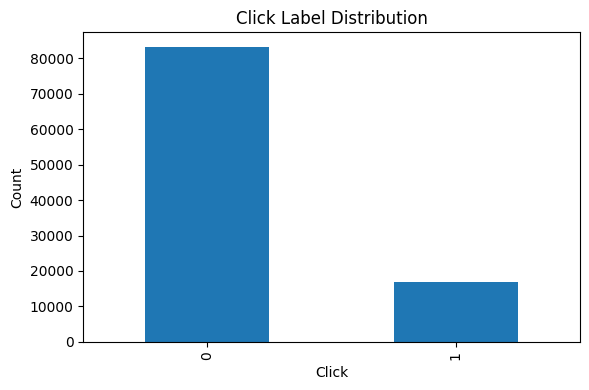

In [12]:

# Visualize the label distribution as a bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title('Click Label Distribution')
plt.xlabel('Click')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


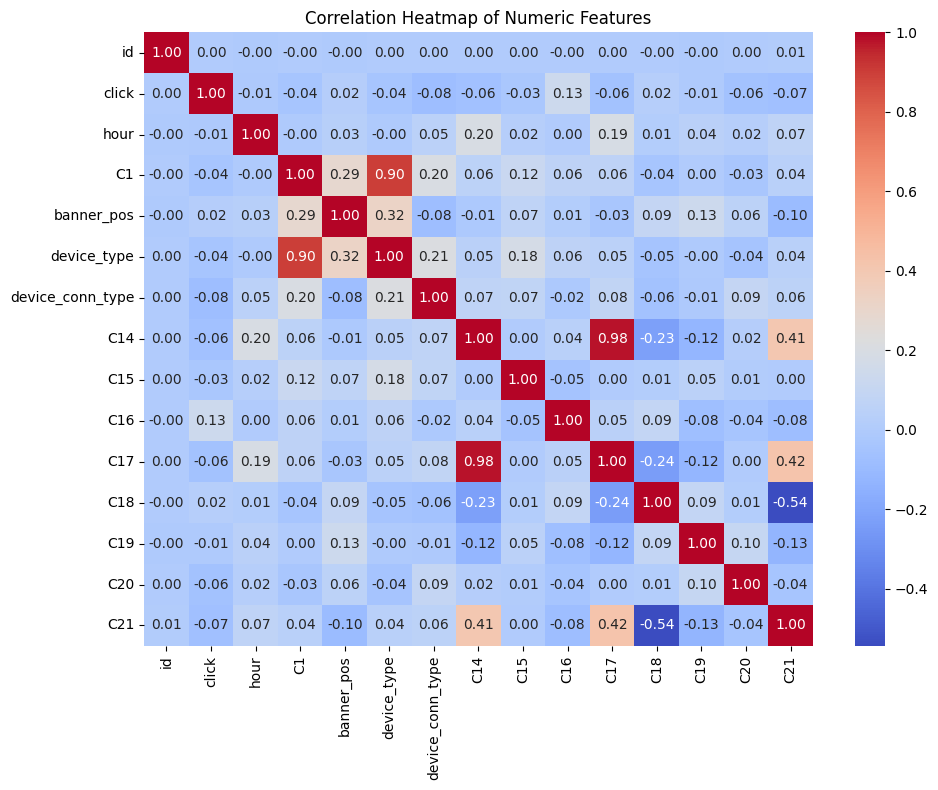

In [13]:

# Correlation heatmap for numeric features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


In [14]:

# Split features and label for modeling
X = df.drop('click', axis=1)
y = df['click']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Because CatBoost can handle categorical features directly, no one-hot encoding is required.
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize CatBoost classifier
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False
)

# Train the model
author_categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]
model.fit(X_train, y_train, cat_features=author_categorical_features)

# Evaluate on validation set
val_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_pred)
print(f"Validation AUC: {auc:.4f}")


Validation AUC: 0.7304


# Preprocessing: Handling Full Dataset with Polars

The full CTR dataset contains tens of millions of rows and cannot be loaded entirely into memory on most machines. To efficiently process it, we use the **Polars** library for fast, memory-efficient operations on large datasets. We also address class imbalance using **SMOTEN** (synthetic minority over-sampling technique for nominal features) and prepare the data for modeling with a train–test split.

Key steps include:

1. **Load the full dataset with Polars.** Use `scan_csv` or `scan_parquet` to lazily read huge files without loading everything into memory.
2. **Chunk processing and necessary transformations.** Apply type conversions, handle missing values if any, and extract features/labels.
3. **Handle class imbalance with SMOTEN.** Oversample the minority class to balance the dataset.
4. **Encode categorical variables and split the data.** Use `ColumnTransformer` and `OneHotEncoder` for models that require numeric input.
5. **Split into training and testing sets.** Use an 80/20 split for training and evaluation.


In [ ]:
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTEN, RandomOverSampler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import scipy.sparse as sp

# 0) Light dtypes
X_work = X_full.copy()
for c in X_work.select_dtypes(include=["object"]).columns:
    X_work[c] = X_work[c].astype("category")
y_work = y_full.astype("int8")

# 1) Current imbalance
counts = y_work.value_counts().sort_index()
minority_label = counts.idxmin()
majority_label = counts.idxmax()
n_min, n_maj = int(counts[minority_label]), int(counts[majority_label])
print("Class counts BEFORE:", counts.to_dict())

# 2) Memory-safe undersampling (caps to keep SMOTEN feasible)
MAX_MINORITY_FOR_SMOTEN = 20_000
RATIO_AFTER_UNDERSAMPLE = 4  # majority <= 4x minority

cap_min = min(n_min, MAX_MINORITY_FOR_SMOTEN)
cap_maj = min(n_maj, RATIO_AFTER_UNDERSAMPLE * cap_min)

if (n_min > cap_min) or (n_maj > cap_maj):
    sampling_strategy = {minority_label: cap_min, majority_label: cap_maj}
    print(f"Undersampling to: {sampling_strategy}")
    rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_step, y_step = rus.fit_resample(X_work, y_work)
else:
    X_step, y_step = X_work, y_work

print("Class counts AFTER undersample:", y_step.value_counts().sort_index().to_dict())

try:
    print("Applying SMOTEN...")
    sm = SMOTEN(random_state=42, k_neighbors=3)  # smaller k reduces compute
    X_bal, y_bal = sm.fit_resample(X_step, y_step)
    print("SMOTEN succeeded.")
except MemoryError:
    print("⚠️ SMOTEN OOM → Falling back to RandomOverSampler.")
    ros = RandomOverSampler(random_state=42)
    X_bal, y_bal = ros.fit_resample(X_step, y_step)

print("Class counts AFTER balancing:", y_bal.value_counts().sort_index().to_dict())

# 4) Sparse one-hot encoding
categorical_cols = X_bal.select_dtypes(include=["category", "object"]).columns.tolist()
numeric_cols = X_bal.select_dtypes(include=[np.number]).columns.tolist()

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True) \
      if "sparse_output" in OneHotEncoder().get_params() \
      else OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# 5) Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Fit/transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# 6) Quick report
def sparse_info(M, name):
    if sp.issparse(M):
        nnz = M.nnz
        total = M.shape[0] * M.shape[1]
        print(f"{name}: shape={M.shape}, nnz={nnz:,}, sparsity={1 - nnz/total:.4f}")
    else:
        print(f"{name}: dense shape={M.shape}")

print("\n DONE")
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
sparse_info(X_train_processed, "X_train_processed")
sparse_info(X_test_processed,  "X_test_processed")


Class counts BEFORE: {0: 248789, 1: 51211}
Undersampling to: {np.int8(1): 20000, np.int8(0): 80000}
Class counts AFTER undersample: {0: 80000, 1: 20000}
Applying SMOTEN...
SMOTEN succeeded.
Class counts AFTER balancing: {0: 80000, 1: 80000}

✅ DONE
Train size: 128000 | Test size: 32000
X_train_processed: shape=(128000, 59534), nnz=2,647,258, sparsity=0.9997
X_test_processed: shape=(32000, 59534), nnz=652,014, sparsity=0.9997



CLASS DISTRIBUTION (Before vs After)
Before balancing:
click
0    248789
1     51211
Name: count, dtype: int64
Ratios (%):
 click
0    82.93%
1    17.07%
Name: count, dtype: object

[Note] 'y_res' not found → cannot show AFTER balancing counts. Run your balancing cell first.


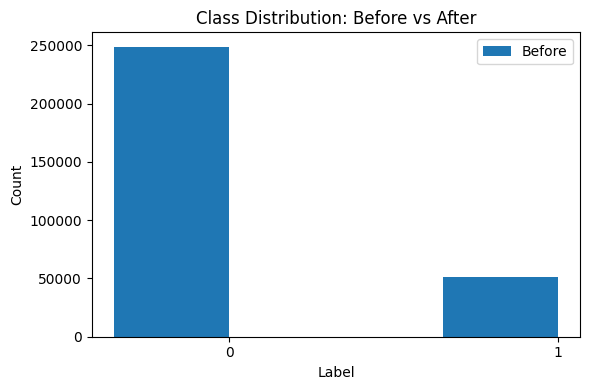


MEMORY USAGE (Object vs Category)
Estimated memory if categoricals were 'object': 179.10 MB
Actual memory with 'category' dtypes:          49.70 MB
Saved approximately:                           129.40 MB

ONE-HOT FOOTPRINT & SPARSITY
Transformed feature dimension (train): 59534
OHE features (if available):          59520
X_train_processed: shape=(128000, 59534), nnz=2,647,258, sparsity=0.9997
X_test_processed: shape=(32000, 59534), nnz=652,014, sparsity=0.9997

SHAPES (Before vs After)
Original sample shape: (300000, 24)
After balancing (X_res): [not available]
Train processed shape:  (128000, 59534)
Test  processed shape:  (32000, 59534)

✅ Diagnostics complete.


In [ ]:
# ============================
# BEFORE vs AFTER (Diagnostics for your pipeline)
# Works with your notebook variables if they exist.
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def _exists(name):
    return name in globals()

def _print_title(t):
    print("\n" + "="*len(t))
    print(t)
    print("="*len(t))

# -------- 0) Sanity: we need full_df and label_col at minimum --------
if not _exists("full_df") or not _exists("label_col"):
    raise NameError("This cell expects at least 'full_df' (pandas DataFrame) and 'label_col' to be defined in your notebook.")

df = full_df.copy()
lbl = label_col

# -------- 1) Class distribution BEFORE vs AFTER (SMOTEN or balancing) --------
_print_title("CLASS DISTRIBUTION (Before vs After)")
before_counts = df[lbl].value_counts().sort_index()
before_ratio = (before_counts / before_counts.sum() * 100).round(2)

print("Before balancing:")
print(before_counts)
print("Ratios (%):\n", before_ratio.astype(str) + "%")

if _exists("y_res"):
    after_counts = y_res.value_counts().sort_index()
    after_ratio  = (after_counts / after_counts.sum() * 100).round(2)
    print("\nAfter balancing (from your pipeline):")
    print(after_counts)
    print("Ratios (%):\n", after_ratio.astype(str) + "%")
else:
    print("\n[Note] 'y_res' not found → cannot show AFTER balancing counts. Run your balancing cell first.")

# Simple bar plot
try:
    fig, ax = plt.subplots(figsize=(6,4))
    x = np.arange(len(before_counts.index))
    width = 0.35
    ax.bar(x - width/2, before_counts.values, width, label="Before")
    if _exists("y_res"):
        ax.bar(x + width/2, y_res.value_counts().sort_index().values, width, label="After")
    ax.set_xticks(x)
    ax.set_xticklabels(before_counts.index.astype(str))
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.set_title("Class Distribution: Before vs After")
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[Plot skipped]", repr(e))

# -------- 2) Memory impact: OBJECT vs CATEGORY casting --------
_print_title("MEMORY USAGE (Object vs Category)")

# simulate 'object' version for categorical columns to estimate the difference
obj_cols_guess = df.select_dtypes(include=["category", "object"]).columns.tolist()
df_as_object = df.copy()
for c in obj_cols_guess:
    df_as_object[c] = df_as_object[c].astype("object")

mem_obj = df_as_object.memory_usage(deep=True).sum() / (1024**2)
mem_cat = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Estimated memory if categoricals were 'object': {mem_obj:,.2f} MB")
print(f"Actual memory with 'category' dtypes:          {mem_cat:,.2f} MB")
print(f"Saved approximately:                           {mem_obj - mem_cat:,.2f} MB")

# -------- 3) One-Hot footprint & sparsity (uses your preprocessor if present) --------
_print_title("ONE-HOT FOOTPRINT & SPARSITY")

def sparsity_info(M, name):
    if sp.issparse(M):
        nnz = M.nnz
        total = M.shape[0] * M.shape[1]
        sparsity = 1 - (nnz / total)
        print(f"{name}: shape={M.shape}, nnz={nnz:,}, sparsity={sparsity:.4f}")
    else:
        print(f"{name}: dense shape={M.shape}")

if _exists("preprocessor") and _exists("X_train_processed") and _exists("X_test_processed"):
    # number of OHE features if retrievable
    try:
        ohe = preprocessor.named_transformers_.get("cat", None)
        if isinstance(ohe, OneHotEncoder):
            n_ohe_features = len(ohe.get_feature_names_out())
        else:
            n_ohe_features = np.nan
    except Exception:
        n_ohe_features = np.nan

    print(f"Transformed feature dimension (train): {X_train_processed.shape[1]}")
    print(f"OHE features (if available):          {n_ohe_features}")
    sparsity_info(X_train_processed, "X_train_processed")
    sparsity_info(X_test_processed,  "X_test_processed")
else:
    print("[Note] 'preprocessor' or transformed matrices not found → cannot report final sparsity.")
    # fallback: approximate number of OHE columns from unique counts (cheap and safe)
    cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()
    approx_ohe = int(sum(df[c].nunique(dropna=True) for c in cat_cols))
    num_cols = len(df.select_dtypes(include=[np.number]).columns)
    print(f"(Approx) OHE columns if encoded: ~{approx_ohe}")
    print(f"(Approx) total transformed dim:   ~{approx_ohe + num_cols}")

# -------- 4) Shapes before/after --------
_print_title("SHAPES (Before vs After)")
print(f"Original sample shape: {df.shape}")
if _exists("X_res"):
    print(f"After balancing (X_res): {X_res.shape}")
else:
    print("After balancing (X_res): [not available]")

if _exists("X_train_processed") and _exists("X_test_processed"):
    print(f"Train processed shape:  {X_train_processed.shape}")
    print(f"Test  processed shape:  {X_test_processed.shape}")
else:
    print("Train/Test processed shapes: [not available]")

print("\n Diagnostics complete.")


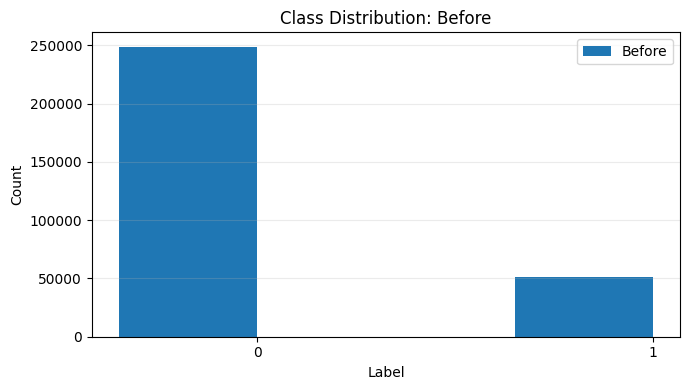

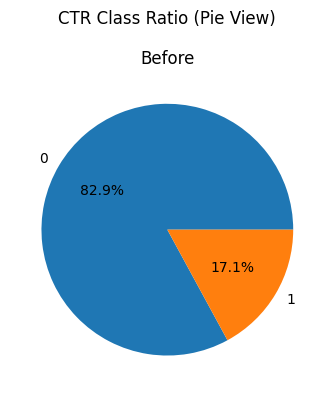

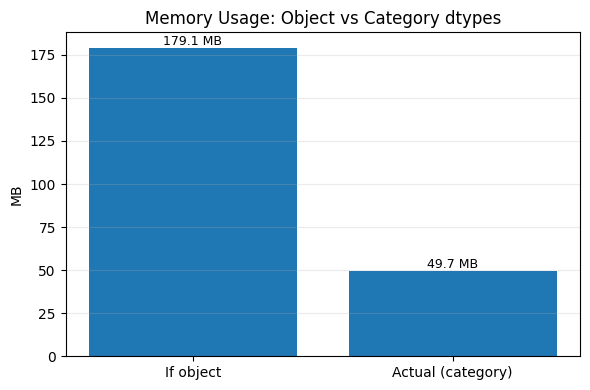

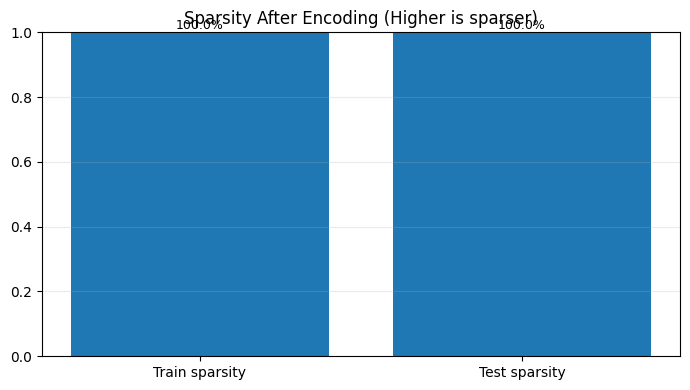

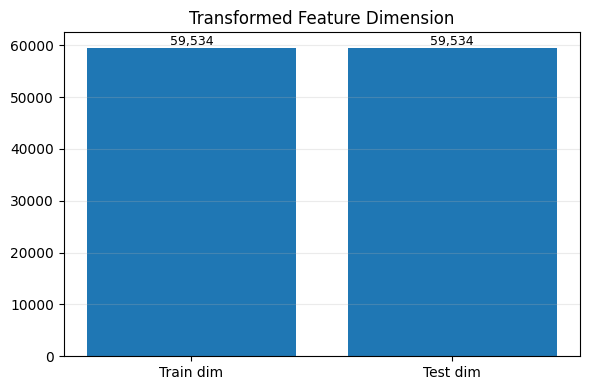

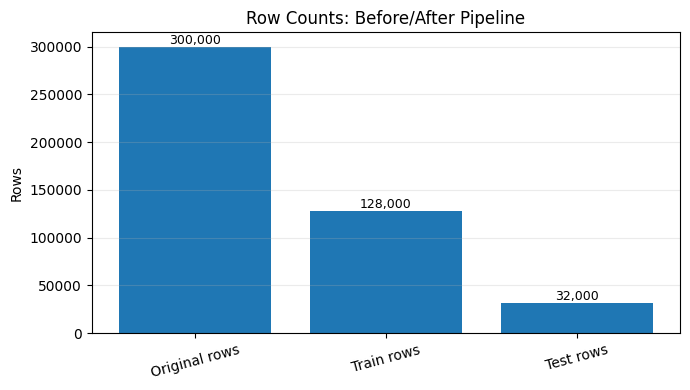

In [26]:
# ============================================================
# Visual BEFORE vs AFTER diagnostics (no heavy prints, plots only)
# Requires: full_df (pandas), label_col (str)
# Optional: y_res, preprocessor, X_train_processed, X_test_processed
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder

plt.close("all")

def exists(name): return name in globals()

# -------- Safety checks --------
if not exists("full_df") or not exists("label_col"):
    raise NameError("This cell needs 'full_df' (pandas DataFrame) and 'label_col' defined earlier.")

df = full_df.copy()
lbl = label_col

# ============================================================
# 1) Class distribution: BEFORE vs AFTER (if y_res exists)
# ============================================================
fig, ax = plt.subplots(figsize=(7,4))
before_counts = df[lbl].value_counts().sort_index()
x = np.arange(len(before_counts.index))
width = 0.35

ax.bar(x - width/2, before_counts.values, width, label="Before")
if exists("y_res"):
    after_counts = y_res.value_counts().sort_index()
    ax.bar(x + width/2, after_counts.values,  width, label="After")
    ax.set_title("Class Distribution: Before vs After")
else:
    ax.set_title("Class Distribution: Before")
ax.set_xticks(x)
ax.set_xticklabels(before_counts.index.astype(str))
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Pie view (optional, nice for presentation)
fig, axs = plt.subplots(1, 2 if exists("y_res") else 1, figsize=(8,4))
if not isinstance(axs, np.ndarray): axs = np.array([axs])

axs[0].pie(before_counts.values, labels=before_counts.index.astype(str), autopct="%1.1f%%")
axs[0].set_title("Before")

if exists("y_res"):
    after_counts = y_res.value_counts().sort_index()
    axs[1].pie(after_counts.values, labels=after_counts.index.astype(str), autopct="%1.1f%%")
    axs[1].set_title("After")

plt.suptitle("CTR Class Ratio (Pie View)")
plt.tight_layout()
plt.show()

# ============================================================
# 2) Memory usage: OBJECT vs CATEGORY
# ============================================================
# Estimate memory if categoricals were 'object'
df_as_object = df.copy()
cat_or_obj_cols = df.select_dtypes(include=["category","object"]).columns.tolist()
for c in cat_or_obj_cols:
    df_as_object[c] = df_as_object[c].astype("object")

mem_obj_mb = df_as_object.memory_usage(deep=True).sum() / (1024**2)
mem_cat_mb = df.memory_usage(deep=True).sum() / (1024**2)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["If object", "Actual (category)"], [mem_obj_mb, mem_cat_mb])
ax.set_title("Memory Usage: Object vs Category dtypes")
ax.set_ylabel("MB")
for i, v in enumerate([mem_obj_mb, mem_cat_mb]):
    ax.text(i, v, f"{v:.1f} MB", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================
# 3) One-Hot footprint & sparsity (if transformed matrices exist)
# ============================================================
have_transformed = exists("X_train_processed") and exists("X_test_processed")
fig, ax = plt.subplots(figsize=(7,4))

if have_transformed:
    # Sparsity = 1 - (nnz / total)
    def sparsity(M):
        if sp.issparse(M):
            return 1.0 - (M.nnz / (M.shape[0]*M.shape[1]))
        # If dense, approximate zero ratio
        return (M==0).sum() / (M.shape[0]*M.shape[1])

    s_train = sparsity(X_train_processed)
    s_test  = sparsity(X_test_processed)
    ax.bar(["Train sparsity", "Test sparsity"], [s_train, s_test])
    ax.set_ylim(0, 1)
    for i, v in enumerate([s_train, s_test]):
        ax.text(i, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title("Sparsity After Encoding (Higher is sparser)")
    ax.grid(axis="y", alpha=0.25)
else:
    ax.text(0.5, 0.5,
            "No transformed matrices found.\nRun your encoding cell first.",
            ha="center", va="center", fontsize=11)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

# Dimensionality bars (if available)
fig, ax = plt.subplots(figsize=(6,4))
if have_transformed:
    dims = [X_train_processed.shape[1], X_test_processed.shape[1]]
    ax.bar(["Train dim", "Test dim"], dims)
    for i, v in enumerate(dims):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
    ax.set_title("Transformed Feature Dimension")
    ax.grid(axis="y", alpha=0.25)
else:
    ax.text(0.5, 0.5, "No transformed matrices to show dimension.", ha="center", va="center", fontsize=11)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

# ============================================================
# 4) Shapes: Original vs After Balancing vs After Encoding
# ============================================================
fig, ax = plt.subplots(figsize=(7,4))
bars = []
labels = []

# Original
labels.append("Original rows")
bars.append(df.shape[0])

# After balancing (X_res)
if exists("X_res"):
    labels.append("After balancing (X_res)")
    bars.append(getattr(X_res, "shape", (0,0))[0])

# Train/Test (processed) rows if available
if have_transformed and exists("y_train") and exists("y_test"):
    labels.extend(["Train rows", "Test rows"])
    bars.extend([len(y_train), len(y_test)])

ax.bar(labels, bars)
for i, v in enumerate(bars):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9, rotation=0)
ax.set_title("Row Counts: Before/After Pipeline")
ax.set_ylabel("Rows")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()




## Conclusion

This notebook provides a comprehensive analysis and preprocessing pipeline for the BadrAbu/CTR_Prediction dataset. We covered:

- **Week 1:** Loaded and explored a 100K sample to understand the data shape, column names, descriptive statistics, unique values, and label distribution.
- **Week 2:** Performed data cleaning by checking for missing values, removing duplicates, and detecting outliers.
- **ADA Section:** Conducted deeper exploratory analysis and recommended using CatBoost or LightGBM for CTR prediction due to their ability to handle high-cardinality categorical features and large-scale data. We trained a simple CatBoost model on the sample and evaluated its AUC.
- **Preprocessing:** Presented a template for processing the full dataset using Polars for efficiency, handling class imbalance with SMOTEN, encoding categorical variables with a column transformer, and splitting the data into training and testing sets.

The **label column for the next task is `click`**, which indicates whether an advertisement was clicked or not【501588860927543†L63-L66】. This label will be used in the preprocessing and modeling steps. By following this notebook, you can scale up from the sample to the full dataset and prepare it for model training.
